In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

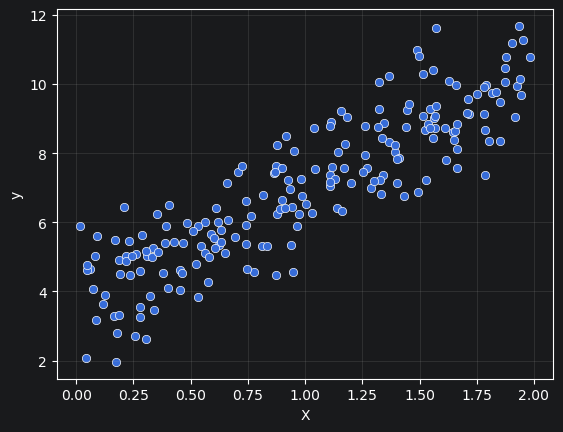

In [3]:
sns.scatterplot(x=X.flatten(), y=y.flatten())
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha=0.2)

In [4]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [5]:
theta_best

array([[3.69084138],
       [3.32960458]])

In [6]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

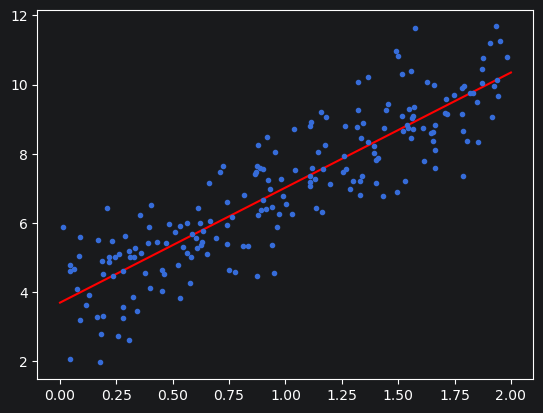

In [7]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, ".")
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(lin_reg.intercept_, lin_reg.coef_)
lin_reg.predict(X_new)

[3.69084138] [[3.32960458]]


array([[ 3.69084138],
       [10.35005055]])

In [9]:
theta_best_svd, residuals, rank, S = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

In [10]:
np.linalg.pinv(X_b) @ y

array([[3.69084138],
       [3.32960458]])

In [11]:
eta = 0.1
n_epochs = 1000
n = len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta -= eta * gradients

theta

array([[3.69084138],
       [3.32960458]])

In [12]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index: random_index + 1]
        yi = y[random_index: random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta -= eta * gradients

theta

array([[3.69826475],
       [3.30748311]])

In [13]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None,
                       eta0=0.01, n_iter_no_change=100, random_state=42)

sgd_reg.fit(X, y.ravel())
print(sgd_reg.intercept_, sgd_reg.coef_)

[3.68899733] [3.33054574]


In [14]:
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[1.64373629]
[1.64373629 2.701869  ]


In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[2.00540719] [[1.11022126 0.50526985]]
